# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Set the variables and the creators for inividuals 
SEED = 14
random.seed(SEED)
np.random.seed(SEED)

# The function that creates an individual of a given length with random 0s and 1s
def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]

# The fitness function that calculates the fitness of an individual by summing its amount of 1's 
def fitness(individual):
    return sum(individual)

# For beauty purposes -> Array to string
def as_string(individual):
    return ''.join(map(str, individual))

# Example of creating an individual and calculating its fitness
rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

00111011111010111100 fitness = 13


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [6]:
# This function creates the contest to see wich individual has the biggest fitness value, and returns a copy of the winner
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()


population = [create_individual(12, rng) for _ in range(8)] # We create 8 chains of 12 bits each
selected = tournament_selection(population, tournament_size=3, rng=rng) # They compete in a tournament of 3 individuals each 
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected)) 

Seleccionado: 110111111001 fitness = 9


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [ ]:
# The function the crossover of the parents to create childrens
# We ought to control a crossover rate, which is the probability of the crossover happening.
#  If the crossover does not happen, the children are copies of the parents.  
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

# Burning example of the crossover function
# In this one especifically, the children are created taking the first "half" of the first parent and the second "half" of the second parent, and vice versa.
p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [8]:
# The algorithm works under controlled probabilities
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate: # If the random number is less than the mutation rate, we flip the bit (0 becomes 1 and 1 becomes 0)
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [ ]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length

    # We create the initial population
    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    # We create a history list to store the best individual, mean fitness, and diversity of the population at each generation
    history = []

    # We iterate over the generations -> improvement of the best individual
    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population] # Calculate the fitness of each individual in the population
        best_index = int(np.argmax(fitnesses)) # Get the index of the individual with the highest fitness
        best = population[best_index].copy() 

        history.append({ 
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        # If the best individual has the maximum fitness or we have reached the maximum number of generations, we stop the algorithm
        if fitness(best) == chromosome_length or generation == generations:
            break

        # We include the best individual in the new population if elitism is enabled
        new_population = [best] if elitism else []

        # We create the new population by selecting parents, performing crossover,
        # and mutating the children until we reach the desired population size
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size, rng)
            parent2 = tournament_selection(population, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        # We got the new population for the next iteration
        population = new_population[:population_size]

    return history[-1]['best_individual'], history # The last one checked individual is the best one, and we return the history of the algorithm

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])

Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


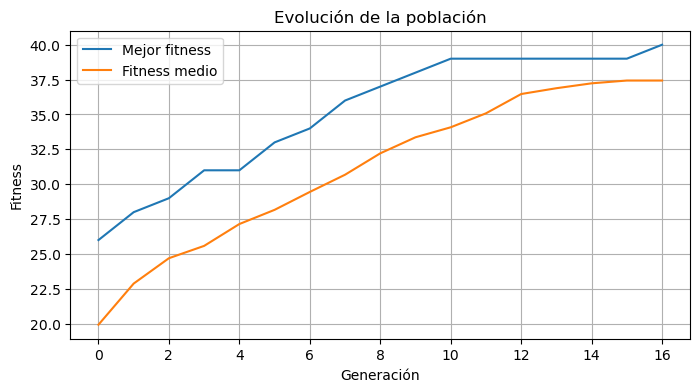

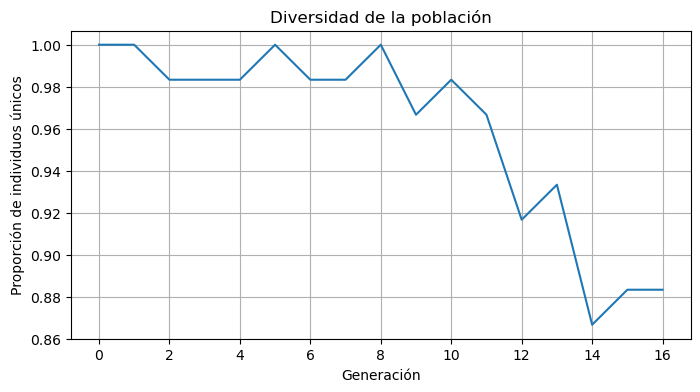

In [10]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [11]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

mutation_rate | fitness medio | generaciones medias
        0.000 |         37.65 |             114.85
        0.005 |         40.00 |              19.90
        0.025 |         40.00 |              16.45
        0.100 |         38.45 |             117.00
        0.500 |         31.75 |             120.00


## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [12]:
# We are changing the way the parents are selected (In tournaments), now we are going to use the roulette selection method, 
# which is a selection method that selects individuals based on their fitness proportionally. 
# The higher the fitness, the higher the chance of being selected.

def roulette_selection(population, rng):
    fitnesses = [fitness(ind) for ind in population] # Calculate the fitness of each individual in the population
    # Calculate the total fitness of the population for having a reference to the probability of each individual being selected
    total_fitness = sum(fitnesses)

    # If they all have a fitness of 0, we select a random individual from the population
    if total_fitness == 0:
        return rng.choice(population).copy()

    # We select a random number between 0 and the total fitness (The picker of the winner)
    pick = rng.random() * total_fitness

    # We iterate over the population and accumulate the fitnesses until we reach the pick value, which means we have found the winner
    current = 0
    for individual, f in zip(population, fitnesses):
        current += f

        if pick < current:
            return individual.copy()

### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [ ]:
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = []
    child2 = []

    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)

    return child1, child2

### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

In [17]:
import string

# We define our target phrase and its alphabet
target = "INTELIGENCIA ARTIFICIAL"
alphabet = string.ascii_uppercase + " "

# Function for creating and individual adapted
def create_individual(length, rng):
    return [rng.choice(alphabet) for _ in range(length)]

# Function for getting the fitness adapted
def fitness(individual):
    # counts the number of characters that are in the correct position
    return sum(
        char == target[i]
        for i, char in enumerate(individual)
    )

# Beauty-purposes function for converting an individual to a string
def as_string(individual):
    return ''.join(individual)


# Same function -> Works as well with the fitness 
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()


# One point crossover the same
def one_point_crossover(parent1, parent2, crossover_rate, rng):

    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    return child1, child2


# Mutation function adapted to the new alphabet
def mutate(individual, mutation_rate, rng):

    child = individual.copy()

    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = rng.choice(alphabet)

    return child


# Full genetic algorithm adapted to the new problem of evolving a phrase
def genetic_algorithm(
    population_size=60,
    generations=150,
    crossover_rate=0.9,
    mutation_rate=0.05,
    tournament_size=3,
    elitism=True, 
    seed=0
):

    rng = random.Random(seed)

    # The length of the chromosome is now determined by the target phrase
    chromosome_length = len(target)

    # Initial population creation
    population = [
        create_individual(chromosome_length, rng)
        for _ in range(population_size)
    ]

    history = []

    # Evolve generation by generation
    for generation in range(generations + 1):

        # We calculate the fitness of all individuals in the population
        fitnesses = [fitness(ind) for ind in population]

        # We find the best individual in the population
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        # Store information about the current generation in the history
        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'best_individual': best
        })

        # Break the loop if we have found the complete phrase
        if fitness(best) == chromosome_length:
            break

        # Elistism: keep the best individual directly in the new population if elitism is enabled
        new_population = [best] if elitism else []

        # Create new population by making changes
        while len(new_population) < population_size:

            # Parents selection
            parent1 = tournament_selection(
                population,
                tournament_size,
                rng
            )

            parent2 = tournament_selection(
                population,
                tournament_size,
                rng
            )

            # Crossover
            child1, child2 = one_point_crossover(
                parent1,
                parent2,
                crossover_rate,
                rng
            )

            # Mutation
            child1 = mutate(
                child1,
                mutation_rate,
                rng
            )

            child2 = mutate(
                child2,
                mutation_rate,
                rng
            )

            # Add the new children to the new population
            new_population.extend([child1, child2])

        # New population for the next generation
        population = new_population[:population_size]

    return history[-1]['best_individual'], history


# Running the genetic algorithm with the specified parameters
best, history = genetic_algorithm(
    population_size=60,
    generations=150,
    crossover_rate=0.9,
    mutation_rate=0.05,
    tournament_size=3,
    elitism=True,
    seed=14
)

print("Mejor individuo:", as_string(best))
print("Fitness:", fitness(best), "/", len(target))
print("Generaciones ejecutadas:", history[-1]['generation'])

Mejor individuo: INTELIGENCIA ARTIFICIAL
Fitness: 23 / 23
Generaciones ejecutadas: 110


### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado.

In [ ]:
# Run with elitism
best_elite, history_elite = genetic_algorithm(
    population_size=60,
    generations=1000,
    crossover_rate=0.9,
    mutation_rate=0.05,
    tournament_size=3,
    elitism=True,
    seed=14
)

# Run without elitism
best_no_elite, history_no_elite = genetic_algorithm(
    population_size=60,
    generations=1000,
    crossover_rate=0.9,
    mutation_rate=0.05,
    tournament_size=3,
    elitism=False,
    seed=14
)


# Get the best fitness of each generation
fitness_elite = [h['best'] for h in history_elite]
fitness_no_elite = [h['best'] for h in history_no_elite]


# Print final results
print("===== CON ELITISMO =====")
print("Mejor individuo:", as_string(best_elite))
print("Fitness final:", fitness(best_elite), "/", len(target))
print("Generaciones:", history_elite[-1]['generation'])

print()

print("===== SIN ELITISMO =====")
print("Mejor individuo:", as_string(best_no_elite))
print("Fitness final:", fitness(best_no_elite), "/", len(target))
print("Generaciones:", history_no_elite[-1]['generation'])


# Check if the best fitness decreases

decreases_elite = any(
    fitness_elite[i] < fitness_elite[i - 1]
    for i in range(1, len(fitness_elite))
)

decreases_no_elite = any(
    fitness_no_elite[i] < fitness_no_elite[i - 1]
    for i in range(1, len(fitness_no_elite))
)

print()
print("¿Disminuyó el mejor fitness con elitismo?", decreases_elite)
print("¿Disminuyó el mejor fitness sin elitismo?", decreases_no_elite)


===== CON ELITISMO =====
Mejor individuo: INTELIGENCIA ARTIFICIAL
Fitness final: 23 / 23
Generaciones: 110

===== SIN ELITISMO =====
Mejor individuo: INTELIGENCIA ARTIFICIAL
Fitness final: 23 / 23
Generaciones: 91

¿Disminuyó el mejor fitness con elitismo? False
¿Disminuyó el mejor fitness sin elitismo? True


### Análisis:

Sí, el mejor fitness puede disminuir de una generación a la siguiente cuando no se utiliza elitismo, ya que el mejor individuo puede perderse durante el cruce o la mutación. En cambio, con elitismo el mejor individuo se copia directamente a la siguiente generación, por lo que el mejor fitness nunca disminuye. En este experimento, ambas configuraciones encontraron la solución óptima de 23/23, aunque sin elitismo lo hizo en menos generaciones (91 frente a 110), mostrando que el elitismo conserva las mejores soluciones, pero no garantiza llegar al óptimo más rápido.

## Preguntas de cierre

1. **¿Qué papel cumple la población que no existe en Hill Climbing?**

En los algoritmos genéticos, la población permite mantener varias soluciones al mismo tiempo, lo que facilita explorar diferentes caminos hacia el óptimo. Además, los individuos pueden combinar sus características mediante el cruce y generar nuevas posibilidades. En cambio, Hill Climbing trabaja con una sola solución y busca mejorarla paso a paso. Por esto, puede quedar atrapado en un óptimo local sin tener otras soluciones que le permitan explorar caminos diferentes.

2. **¿Por qué el cruce no garantiza hijos mejores que sus padres?**

El cruce simplemente combina los genes de dos padres, pero no sabe qué combinación será mejor. Al juntar diferentes partes de los padres, puede ocurrir que se pierdan características que contribuían a un buen fitness. Por eso, un hijo puede tener un fitness menor, igual o mayor que el de sus padres. La selección y las generaciones sucesivas son las que permiten que las combinaciones favorables tengan más posibilidades de mantenerse.

3. **¿Qué significa convergencia prematura?**

Es cuando la población se vuelve muy similar demasiado pronto y dificulta la posibilidad de explorar nuevas soluciones, quedándose atrapada en una solución que puede no ser la óptima.

4. **¿Qué parámetros controlan la exploración?**

Principalmente la tasa de mutación, la tasa de cruce y el tamaño del torneo. Una mayor mutación introduce más cambios y aumenta la diversidad, mientras que el cruce permite combinar características diferentes. Por otro lado, un torneo más pequeño reduce la presión de selección y permite que individuos menos buenos también sean escogidos.